In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import os
import gymnasium
from rl_project.experiments.frozen_lake.frozenlake_utils import make_frozenlake_env, create_frozenlake_safety_rashomon_dataset

sns.set_style("whitegrid")

In [74]:
def from_obs_to_location(obs):
    "Convert one-hot encoded observation to location index."
    return int(np.argmax(obs[:-1]))  # Ignore the last element which is the task label

def stable_softmax(x, tau: float = 1.0):
    e = np.exp((x - x.max()) / tau)
    return e / e.sum()

def generate_observations_task1(env, task_num=0):
    "Generate all observations in task 1 (ignoring the last element which is the task label)."
    obs_dim = env.observation_space.shape[0]
    num_locations = env.nrow * env.ncol
    assert num_locations + 1 == obs_dim, "Observation dimension should be number of locations plus one for task label." 
    for location in range(num_locations):
        cur_obs = np.zeros(obs_dim, dtype=np.float32)
        cur_obs[location] = 1.0
        cur_obs[-1] = float(task_num)
        yield cur_obs

### Load results

In [2]:
cfg_name = 'standard_4x4'
seed_num = 0

env_folder = '/vol/bitbucket/ma5923/_projects/CertifiedContinualLearning/rl_project/experiments/frozen_lake'
folder_path = f'/vol/bitbucket/ma5923/_projects/CertifiedContinualLearning/rl_project/experiments/frozen_lake/outputs/{cfg_name}/{seed_num}/downstream'
rashomon_bounded_model_path = f'{folder_path}/bounded_model.pt'
rashomon_bounded_model = torch.load(rashomon_bounded_model_path, weights_only=False, map_location='cpu')

rashomon_bounded_model

IntervalBoundedModel(
	self.modules=[
		Linear(in_features=17, out_features=64, bias=True)
		ReLU()
		Linear(in_features=64, out_features=64, bias=True)
		ReLU()
		Linear(in_features=64, out_features=4, bias=True)
	],
	self.interval_matmul='rump',
	self.trainable=True,
)

In [39]:
env_id = 'FrozenLake-v1'

# Load configuration file for FrozenLake
configs_path = os.path.join(env_folder, 'configs.yaml')
with open(configs_path) as f:
    all_cfgs = yaml.safe_load(f)

cfg = all_cfgs[cfg_name]
env1_map = cfg["env1_map"]
is_slippery: bool = bool(cfg.get("is_slippery", False))

# Create the FrozenLake environment using the loaded configuration
task1_env = make_frozenlake_env(env_map=env1_map, task_num=0, is_slippery=is_slippery)

# Load Rashomon dataset
rashomon_dataset = torch.load(f'{folder_path}/rashomon_dataset.pt', weights_only=False, map_location='cpu')

# Create states
task1_observations = np.array(list(generate_observations_task1(task1_env)))
safety_critical_task1_observations = rashomon_dataset.tensors[0].numpy()

In [32]:
allowed_actions_per_critical_state_dct = {
    from_obs_to_location(safety_critical_task1_observations[i]): list(map(int, list(np.where(rashomon_dataset.tensors[1][i, :].numpy()== 1)[0])))
    for i in range(safety_critical_task1_observations.shape[0])
}
allowed_actions_per_critical_state_dct

{1: [0, 2, 3],
 3: [0, 2, 3],
 4: [0, 1, 3],
 6: [1, 3],
 8: [0, 2, 3],
 9: [0, 1, 2],
 10: [0, 1, 3],
 13: [1, 2, 3]}

In [34]:
n_actions = task1_env.action_space.n
action_labels = {
    0: 'Left',
    1: 'Down',
    2: 'Right',
    3: 'Up'
}

### Visualise logit Rashomon bounds across all states

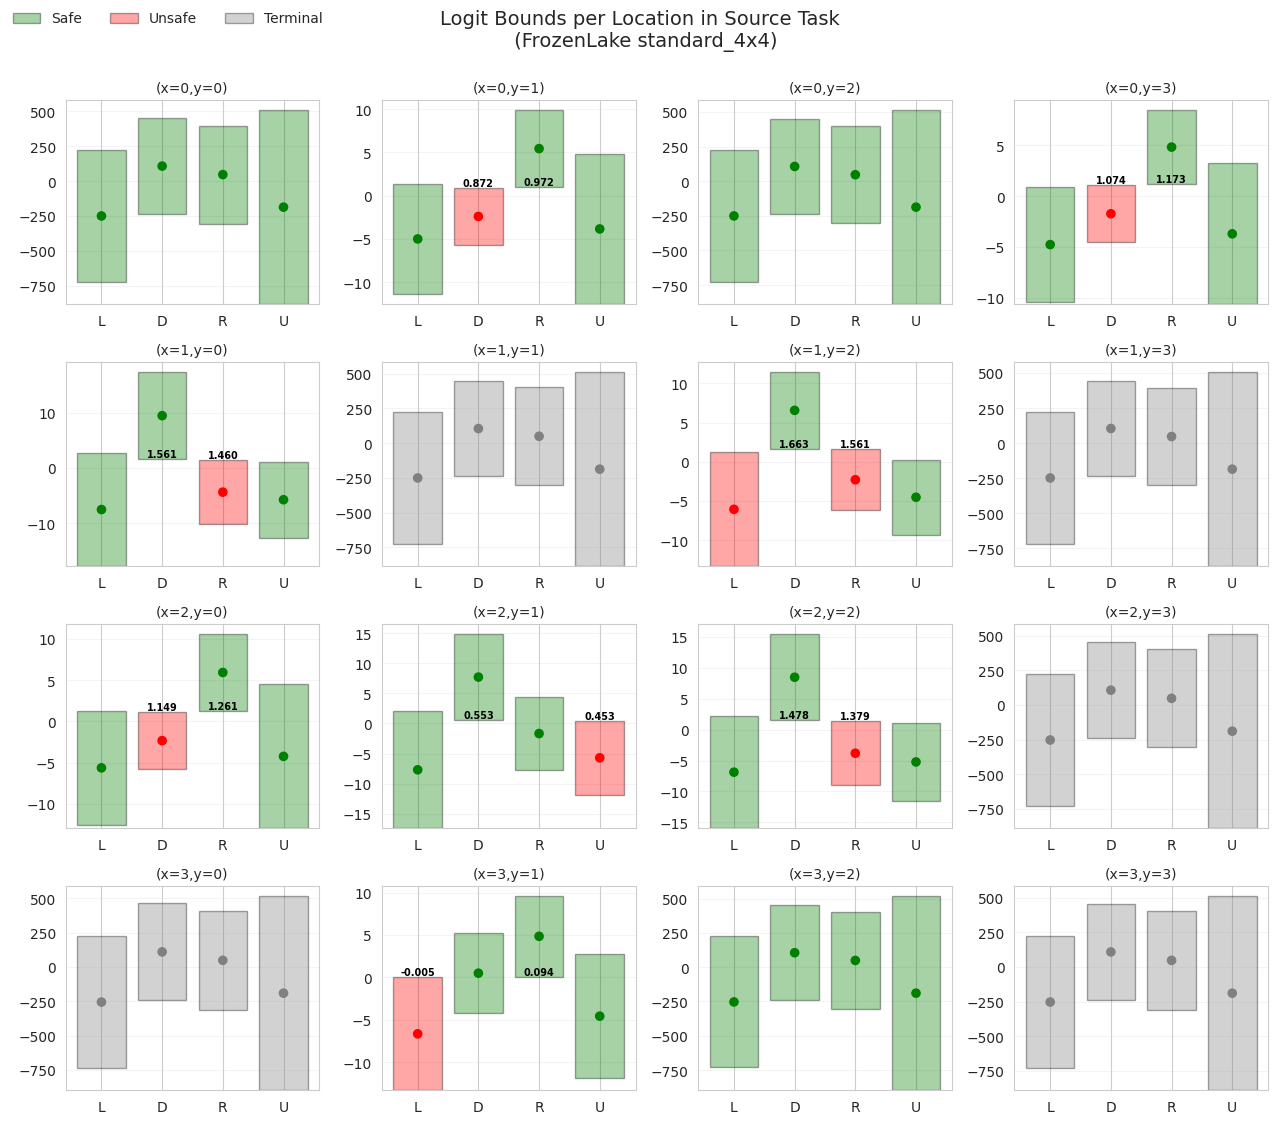

In [70]:
# Visualize per-state logit intervals from a saved/loaded bounded_model.
# Safe actions are green, unsafe actions red.

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ---- required inputs ----
# 1) bounded_model: IntervalBoundedModel (already in memory or loaded)
# 2) env_map: list[str], e.g. from configs.yaml
#    env_map = ["SFFF","FHFH","FFFH","HFFG"]

# Optional: if you need to load bounded_model
# bounded_model = torch.load(".../downstream/bounded_model.pt", map_location="cpu")

action_names = ["L", "D", "R", "U"]
deltas = {0: (0, -1), 1: (1, 0), 2: (0, 1), 3: (-1, 0)}

grid = [list(row) for row in env1_map]
nrows, ncols = len(grid), len(grid[0])
n_states = nrows * ncols

# Infer input dim from first linear layer of bounded_model
in_dim = rashomon_bounded_model.param_n[0].shape[1]
has_task_flag = (in_dim == n_states + 1)

def rc_to_s(r, c):
    return r * ncols + c

def state_obs(s, task_flag=0.0):
    x = np.zeros(in_dim, dtype=np.float32)
    x[s] = 1.0
    if has_task_flag:
        x[-1] = float(task_flag)
    return x

def safe_actions_for_state(r, c):
    cell = grid[r][c]
    # Terminal states: no meaningful safe/unsafe action split
    if cell in ("H", "G"):
        return None
    safe = []
    hole_states = {rc_to_s(rr, cc) for rr in range(nrows) for cc in range(ncols) if grid[rr][cc] == "H"}
    for a, (dr, dc) in deltas.items():
        nr, nc = r + dr, c + dc
        hits_wall = (nr < 0 or nr >= nrows or nc < 0 or nc >= ncols)
        if hits_wall:
            safe.append(a)  # wall-hit stays in place, safe
        else:
            ns = rc_to_s(nr, nc)
            if ns not in hole_states:
                safe.append(a)
    return set(safe)

# Build all observations in grid order
X = torch.tensor(
    np.stack([state_obs(rc_to_s(r, c), task_flag=0.0) for r in range(nrows) for c in range(ncols)]),
    dtype=torch.float32
)

with torch.no_grad():
    lb, ub = rashomon_bounded_model.bound_forward(X, X)  # shape: [n_states, 4]
    lb = lb.cpu().numpy()
    ub = ub.cpu().numpy()
    mid = 0.5 * (lb + ub)

fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.8 * nrows), squeeze=False)

for r in range(nrows):
    for c in range(ncols):
        ax = axes[r, c]
        s = rc_to_s(r, c)
        safe_set = safe_actions_for_state(r, c)

        # Color each action bar by safety
        colors = []
        highest_safe_lower_bound, highest_safe_lower_bound_idx = -np.inf, None
        highest_unsafe_upper_bound, highest_unsafe_upper_bound_idx = -np.inf, None
        for a in range(4):
            if safe_set is None:
                colors.append("gray")  # terminal states
            else:
                colors.append("green" if a in safe_set else "red")
                if a in safe_set:
                    if lb[s][a] > highest_safe_lower_bound:
                        highest_safe_lower_bound = lb[s][a]
                        highest_safe_lower_bound_idx = a
                else:
                    if ub[s][a] > highest_unsafe_upper_bound:
                        highest_unsafe_upper_bound = ub[s][a]
                        highest_unsafe_upper_bound_idx = a

        # Draw interval bars [lb, ub]
        heights = ub[s] - lb[s]
        ax.bar(np.arange(4), heights, bottom=lb[s], color=colors, alpha=0.35, edgecolor="black")
        ax.scatter(np.arange(4), mid[s], c=colors, s=35, zorder=3)

        cell = grid[r][c]
        # ax.set_title(f"(x={r},y={c}) {cell}", fontsize=10)
        ax.set_title(f"(x={r},y={c})", fontsize=10)
        ax.set_xticks(np.arange(4))
        ax.set_xticklabels(action_names)
        ax.grid(axis="y", alpha=0.2)

        # # Add text annotations for upper and lower bounds
        # for a_idx in range(n_actions):
        #     ax.text(
        #         a_idx, ub[s][a_idx],
        #         f"{ub[s][a_idx]:.3f}",
        #         ha='center', va='bottom', fontsize=7, color='black', fontweight='bold'
        #     )
        #     ax.text(
        #         a_idx, lb[s][a_idx],
        #         f"{lb[s][a_idx]:.3f}",
        #         ha='center', va='top', fontsize=7, color='black', fontweight='bold'
        #     )
        if highest_unsafe_upper_bound_idx is not None:
            ax.text(
                highest_safe_lower_bound_idx, highest_safe_lower_bound,
                f"{highest_safe_lower_bound:.3f}",
                ha='center', va='bottom', fontsize=7, color='black', fontweight='bold'
            )
            ax.text(
                highest_unsafe_upper_bound_idx, highest_unsafe_upper_bound,
                f"{highest_unsafe_upper_bound:.3f}",
                ha='center', va='bottom', fontsize=7, color='black', fontweight='bold'
            )

# Shared legend
legend_handles = [
    Patch(facecolor="green", edgecolor="black", alpha=0.35, label="Safe"),
    Patch(facecolor="red", edgecolor="black", alpha=0.35, label="Unsafe"),
    Patch(facecolor="gray", edgecolor="black", alpha=0.35, label="Terminal"),
]
fig.legend(handles=legend_handles, loc="upper left", ncol=3, frameon=False)

fig.suptitle(f"Logit Bounds per Location in Source Task \n (FrozenLake {cfg_name})", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()


### Visualise the softmax for worst-case logit across all safety-critical states

In [72]:
# Visualise the softax of the worst-case logits per safety-critical state across the Rashomon set, and compare to the source policy's softmax outputs in those states
logit_bounds = rashomon_bounded_model.bound_forward(
    torch.tensor(task1_observations, dtype=torch.float32),
    torch.tensor(task1_observations, dtype=torch.float32)
)

worst_case_logits_per_state = {}
for state_idx in range(n_states):
    
    with torch.no_grad():
        logit_l = logit_bounds[0][state_idx].numpy()
        logit_u = logit_bounds[1][state_idx].numpy()

    # NOTE: if no safe actions, then the state is safe for any action -> 
    cur_allowed_actions = allowed_actions_per_critical_state_dct.get(state_idx, None)
    if cur_allowed_actions is None:
        # worst_case_logits_per_state[state_idx] = None
        continue

    # For each safe action, take the lower bound; for each unsafe action, take the upper bound; then combine to get the worst-case logit vector across the Rashomon set
    safe_actions_flags = np.array([a in cur_allowed_actions for a in range(n_actions)])
    worst_case_logit = np.where(
        safe_actions_flags,
        logit_l,
        logit_u
    )
    best_case_logit = np.where(
        safe_actions_flags,
        logit_u,
        logit_l,
    )

    result_df = pd.DataFrame({'worst-case logit': worst_case_logit, 'best-case logit': best_case_logit, 'safe action': safe_actions_flags})

    # worst_case_prob = stable_softmax(worst_case_logit)
    worst_case_logits_per_state[state_idx] = result_df

In [75]:
worst_case_logits_per_state

{1:    worst-case logit  best-case logit  safe action
 0        -11.369972         1.340593         True
 1          0.872431        -5.696343        False
 2          0.971685         9.892921         True
 3        -12.570464         4.854750         True,
 3:    worst-case logit  best-case logit  safe action
 0        -10.400389         0.861778         True
 1          1.074143        -4.554346        False
 2          1.173281         8.448823         True
 3        -10.633501         3.208507         True,
 4:    worst-case logit  best-case logit  safe action
 0        -17.791376         2.735178         True
 1          1.560677        17.336693         True
 2          1.460062       -10.226740        False
 3        -12.654501         1.142312         True,
 6:    worst-case logit  best-case logit  safe action
 0          1.193975       -13.331570        False
 1          1.663049        11.434207         True
 2          1.561326        -6.158543        False
 3         -9.28

In [ ]:
safety_critical_task1_observations

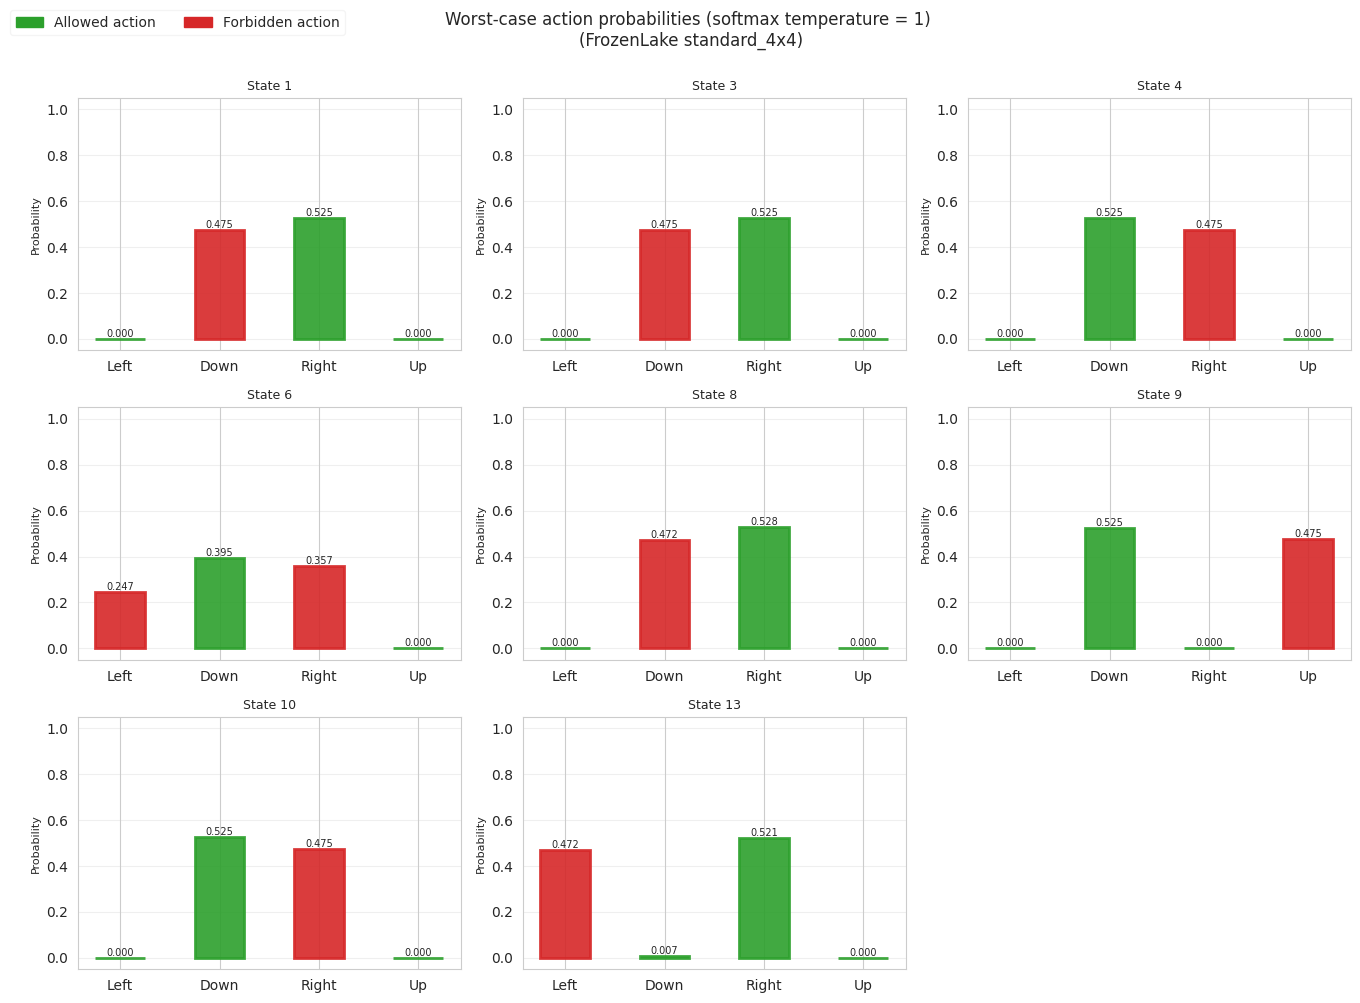

In [ ]:
# Plot worst-case action probabilities per safety-critical state
temperature = 1

state_ids = list(worst_case_logits_per_state.keys())
n_plots = len(state_ids)
ncols_plot = 3
nrows_plot = int(np.ceil(n_plots / ncols_plot))

fig, axes = plt.subplots(
    nrows=nrows_plot,
    ncols=ncols_plot,
    figsize=(4.5 * ncols_plot, 3.5 * nrows_plot),
    squeeze=False
)

for idx, state_idx in enumerate(state_ids):
    ax = axes[idx // ncols_plot, idx % ncols_plot]

    cur_df = worst_case_logits_per_state[state_idx]
    worst_case_logit = cur_df["worst-case logit"].values
    safe_flags = cur_df["safe action"].values.astype(bool)

    worst_case_prob = stable_softmax(worst_case_logit, tau=temperature)
    bar_colors = np.where(safe_flags, "tab:green", "tab:red")

    ax.bar(
        x=action_labels.values(),
        height=worst_case_prob,
        color=bar_colors,
        edgecolor=bar_colors,
        linewidth=2,
        alpha=0.9,
        width=0.5
    )

    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f"State {state_idx}", fontsize=9)
    ax.set_ylabel("Probability", fontsize=8)
    ax.grid(axis="y", alpha=0.3)

    for i, prob in enumerate(worst_case_prob):
        ax.text(i, prob, f"{prob:.3f}", ha="center", va="bottom", fontsize=7)

# Hide unused axes
for idx in range(n_plots, nrows_plot * ncols_plot):
    axes[idx // ncols_plot, idx % ncols_plot].set_visible(False)

# Legend for bar colors
legend_handles = [
    Patch(facecolor="tab:green", edgecolor="tab:green", label="Safe"),
    Patch(facecolor="tab:red", edgecolor="tab:red", label="Unsafe"),
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.12, 0.92),
    ncol=2,
    fontsize=10,
    framealpha=0.2,
)

fig.suptitle(f"Worst-case action probabilities (softmax temperature = {temperature}) \n(FrozenLake {cfg_name})", y=0.95)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [77]:
action_labels

{0: 'Left', 1: 'Down', 2: 'Right', 3: 'Up'}